<a href="https://colab.research.google.com/github/Shaurya-XD/diabetic_retinopathy/blob/main/DR_Screening_RESUME_FIX_ONLY_EXISTING_FILES.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DR Screening — Resume Notebook: Fix Remaining Sections Without Retraining

This notebook is designed for the **new Colab account** after the successful training run.

It does **not retrain APTOS EfficientNet or IDRiD segmentation**. Instead, it loads the final checkpoints from the previous run and replaces the problematic portion that began around the old **Cell 34**:

1. robust checkpoint restoration,
2. corrected explainability evaluation,
3. robust handling of the existing `messidor-2.csv`,
4. external Messidor validation **only if that CSV actually contains DR labels**,
5. final report generation,
6. final combined summary.

## Transfer these files to the new account's Google Drive

Create:

`MyDrive/sih/outputs_v3/`

and copy these three files into it:

- `aptos_efficientnetb0_final.keras`
- `idrid_lesion_unet_final.weights.h5`
- `run_summary.json`

For the remaining evaluation, also make available the files you already have:

- `A. Segmentation.zip`
- `messidor-2.csv`
- `IMAGES.zip.001`
- `IMAGES.zip.002`
- `IMAGES.zip.003`
- `IMAGES.zip.004`

If Messidor-2 is already extracted, you may instead put the extracted image folder at:

`MyDrive/sih/Messidor2/`

### You do NOT need to transfer

- `classifier_head_best.keras`
- `classifier_finetuned_best.keras`
- `seg_stage1_best.weights.h5`
- `seg_stage2_best.weights.h5`
- the APTOS 2019 archive
- IDRiD Disease Grading archive
- IDRiD Localization archive

The previous internal APTOS metrics, temperature, referral threshold, and segmentation metrics are recovered from `run_summary.json`.

## Important Messidor note

This notebook uses **only the `messidor-2.csv` file you already have**.

The old notebook failed because it searched for a narrow set of expected header names. This version reads the CSV with multiple possible delimiters, prints its actual schema, identifies image-reference columns by matching values against the extracted Messidor filenames, and searches for a plausible DR-grade column.

If `messidor-2.csv` genuinely contains no DR-grade labels, the notebook will **not fabricate labels**. External quantitative validation will be skipped cleanly, while the rest of the pipeline and Messidor inference/report demonstration will still run.


In [1]:
# Cell 1 — Install lightweight runtime dependencies
!pip -q install reportlab rarfile psutil


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 31.7 MB/s eta 0:00:00


In [2]:
# Cell 2 — Imports and reproducibility
import os
import sys
import json
import math
import csv
import shutil
import zipfile
import subprocess
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    accuracy_score,
    cohen_kappa_score,
    ConfusionMatrixDisplay,
)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

GPUS = tf.config.list_physical_devices("GPU")
for gpu in GPUS:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except Exception:
        pass

print("Python:", sys.version.split()[0])
print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)
print("GPU:", GPUS if GPUS else "Not detected")


Python: 3.13.15
TensorFlow: 2.20.0
Keras: 3.13.2
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# Cell 3 — Mount the NEW Google Drive and verify the handoff
from google.colab import drive
drive.mount("/content/drive")

DRIVE_ROOT = Path("/content/drive/MyDrive/sih")
OUTPUT_ROOT = DRIVE_ROOT / "outputs_v3"
WORK_ROOT = Path("/content/dr_resume_work")
FIXED_OUTPUT_ROOT = DRIVE_ROOT / "outputs_v3_fixed"

WORK_ROOT.mkdir(parents=True, exist_ok=True)
FIXED_OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

FINAL_CLASSIFIER = OUTPUT_ROOT / "aptos_efficientnetb0_final.keras"
FINAL_SEG_WEIGHTS = OUTPUT_ROOT / "idrid_lesion_unet_final.weights.h5"
RUN_SUMMARY = OUTPUT_ROOT / "run_summary.json"

required_checkpoints = [
    FINAL_CLASSIFIER,
    FINAL_SEG_WEIGHTS,
    RUN_SUMMARY,
]

missing = [str(p) for p in required_checkpoints if not p.exists()]

if missing:
    raise FileNotFoundError(
        "Missing required handoff files:\n- " + "\n- ".join(missing)
    )

print("Checkpoint handoff verified.")
print("Classifier:", FINAL_CLASSIFIER)
print("Segmentation weights:", FINAL_SEG_WEIGHTS)
print("Summary:", RUN_SUMMARY)
print("New fixed outputs:", FIXED_OUTPUT_ROOT)


Mounted at /content/drive
Checkpoint handoff verified.
Classifier: /content/drive/MyDrive/sih/outputs_v3/aptos_efficientnetb0_final.keras
Segmentation weights: /content/drive/MyDrive/sih/outputs_v3/idrid_lesion_unet_final.weights.h5
Summary: /content/drive/MyDrive/sih/outputs_v3/run_summary.json
New fixed outputs: /content/drive/MyDrive/sih/outputs_v3_fixed


In [4]:
# Cell 4 — Restore successful-run constants and metrics
with open(RUN_SUMMARY, "r", encoding="utf-8") as f:
    previous_summary = json.load(f)

CLS_SIZE = tuple(previous_summary["config"]["cls_size"])
SEG_SIZE = tuple(previous_summary["config"]["seg_size"])

TEMPERATURE = float(previous_summary["classifier"]["temperature"])
REF_THRESHOLD = float(previous_summary["classifier"]["referral_threshold"])

SEG_THRESHOLD = float(previous_summary["segmentation"]["validation_threshold"])

print("Recovered settings:")
print("CLS_SIZE:", CLS_SIZE)
print("SEG_SIZE:", SEG_SIZE)
print("Temperature:", TEMPERATURE)
print("Referral threshold:", REF_THRESHOLD)
print("Segmentation threshold:", SEG_THRESHOLD)

print("\nPreviously validated APTOS metrics:")
for k, v in previous_summary["classifier"].items():
    if k.startswith("aptos_test_"):
        print(k, "=", v)

print("\nPreviously validated IDRiD segmentation metrics:")
for k, v in previous_summary["segmentation"].items():
    if k.startswith("validation_"):
        print(k, "=", v)


Recovered settings:
CLS_SIZE: (300, 300)
SEG_SIZE: (384, 384)
Temperature: 0.8320230381499122
Referral threshold: 0.3188608191210113
Segmentation threshold: 0.8500000000000002

Previously validated APTOS metrics:
aptos_test_accuracy = 0.7727272727272727
aptos_test_qwk = 0.8201732875592611
aptos_test_referable_auc = 0.9698852182498869
aptos_test_sensitivity = 0.905829596412556
aptos_test_specificity = 0.8899082568807339

Previously validated IDRiD segmentation metrics:
validation_threshold = 0.8500000000000002
validation_dice = 0.5435399836088107
validation_iou = 0.3731925198716067
validation_precision = 0.5073841824118475
validation_recall = 0.5852440158212389


In [5]:
# Cell 5 — Load final classifier checkpoint directly (NO retraining)
model = keras.models.load_model(FINAL_CLASSIFIER, compile=False)

print("Classifier restored.")
print("Model name:", model.name)
print("Input shape:", model.input_shape)
print("Output shape:", model.output_shape)

if tuple(model.input_shape[1:3]) != tuple(CLS_SIZE):
    raise RuntimeError(
        f"Classifier checkpoint input size {model.input_shape[1:3]} "
        f"does not match run summary {CLS_SIZE}."
    )


Classifier restored.
Model name: DR_EfficientNetB0
Input shape: (None, 300, 300, 3)
Output shape: (None, 5)


In [6]:
# Cell 6 — Rebuild segmentation architecture WITHOUT downloading ImageNet weights
# The final checkpoint already contains the trained encoder + decoder weights,
# so weights=None prevents the previous MobileNetV2 224x224 warning/download.

def decoder_block(x, skip, filters, name):
    x = layers.Conv2DTranspose(
        filters,
        kernel_size=3,
        strides=2,
        padding="same",
        use_bias=False,
        name=name + "_up",
    )(x)

    x = layers.Concatenate(name=name + "_concat")([x, skip])

    x = layers.Conv2D(
        filters, 3, padding="same", use_bias=False,
        name=name + "_conv1"
    )(x)
    x = layers.BatchNormalization(name=name + "_bn1")(x)
    x = layers.Activation("relu", name=name + "_relu1")(x)

    x = layers.Conv2D(
        filters, 3, padding="same", use_bias=False,
        name=name + "_conv2"
    )(x)
    x = layers.BatchNormalization(name=name + "_bn2")(x)
    x = layers.Activation("relu", name=name + "_relu2")(x)

    return x

def build_lesion_unet_for_restore():
    base = keras.applications.MobileNetV2(
        input_shape=(*SEG_SIZE, 3),
        include_top=False,
        weights=None,  # final checkpoint supplies all learned weights
    )

    skip_names = [
        "block_1_expand_relu",
        "block_3_expand_relu",
        "block_6_expand_relu",
        "block_13_expand_relu",
        "block_16_project",
    ]

    encoder = keras.Model(
        base.input,
        [base.get_layer(name).output for name in skip_names],
        name="mobilenetv2_encoder",
    )

    inputs = keras.Input((*SEG_SIZE, 3), name="seg_fundus")

    x = layers.Rescaling(
        scale=1.0 / 127.5,
        offset=-1.0,
        name="mobilenet_preprocess",
    )(inputs)

    s1, s2, s3, s4, bottleneck = encoder(x, training=False)

    x = decoder_block(bottleneck, s4, 256, "dec4")
    x = decoder_block(x, s3, 128, "dec3")
    x = decoder_block(x, s2, 64, "dec2")
    x = decoder_block(x, s1, 32, "dec1")

    x = layers.Conv2DTranspose(
        24,
        3,
        strides=2,
        padding="same",
        activation="relu",
        name="final_up",
    )(x)

    outputs = layers.Conv2D(
        1,
        1,
        activation="sigmoid",
        name="lesion_probability",
    )(x)

    return keras.Model(inputs, outputs, name="IDRiD_Lesion_UNet")

seg_model = build_lesion_unet_for_restore()

# Do NOT compile before loading: avoids the previous optimizer-variable warning.
seg_model.load_weights(FINAL_SEG_WEIGHTS)

print("Segmentation checkpoint restored without optimizer state.")
print("Input shape:", seg_model.input_shape)
print("Output shape:", seg_model.output_shape)


Segmentation checkpoint restored without optimizer state.
Input shape: (None, 384, 384, 3)
Output shape: (None, 384, 384, 1)


In [7]:
# Cell 7 — Shared retinal preprocessing
IMG_EXTS = {".jpg", ".jpeg", ".png", ".tif", ".tiff", ".bmp"}

def fundus_bbox_bgr(img, threshold=10):
    if img is None or img.size == 0:
        return None

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    coords = np.argwhere(gray > threshold)

    if len(coords) == 0:
        h, w = gray.shape
        return 0, h, 0, w

    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0) + 1
    return int(y0), int(y1), int(x0), int(x1)

def tf_crop_black_border(img, threshold=10.0):
    gray = tf.reduce_mean(img, axis=-1)
    coords = tf.where(gray > threshold)

    def do_crop():
        y0 = tf.reduce_min(coords[:, 0])
        y1 = tf.reduce_max(coords[:, 0]) + 1
        x0 = tf.reduce_min(coords[:, 1])
        x1 = tf.reduce_max(coords[:, 1]) + 1
        return img[y0:y1, x0:x1, :]

    return tf.cond(
        tf.shape(coords)[0] > 0,
        do_crop,
        lambda: img,
    )

def decode_classifier_image(path):
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.cast(img, tf.float32)
    img = tf_crop_black_border(img)
    img = tf.image.resize(img, CLS_SIZE, antialias=True)
    return tf.clip_by_value(img, 0.0, 255.0)

def load_classifier_image(filepath):
    return decode_classifier_image(
        tf.constant(str(filepath))
    ).numpy().astype(np.float32)

def prepare_segmentation_image(filepath):
    bgr = cv2.imread(str(filepath))
    if bgr is None:
        raise ValueError(f"Unreadable image: {filepath}")

    bbox = fundus_bbox_bgr(bgr)
    y0, y1, x0, x1 = bbox
    crop = bgr[y0:y1, x0:x1]

    rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
    rgb = cv2.resize(
        rgb,
        (SEG_SIZE[1], SEG_SIZE[0]),
        interpolation=cv2.INTER_AREA,
    )

    return rgb.astype(np.float32)

def temperature_scale(probs, temperature=TEMPERATURE):
    probs = np.clip(np.asarray(probs, np.float64), 1e-12, 1.0)
    logits = np.log(probs) / float(temperature)
    logits -= logits.max(axis=1, keepdims=True)
    e = np.exp(logits)
    return e / e.sum(axis=1, keepdims=True)

def index_images(root):
    rows = []
    if root is None:
        return pd.DataFrame(columns=["filepath", "filename", "stem"])

    for p in Path(root).rglob("*"):
        if p.is_file() and p.suffix.lower() in IMG_EXTS:
            rows.append({
                "filepath": str(p),
                "filename": p.name,
                "stem": p.stem,
            })

    return pd.DataFrame(rows)


# Replacement for the old problematic Grad-CAM section

The previous notebook judged Grad-CAM from **one IDRiD image** and targeted the model's predicted grade. That single image was predicted as Grade 0, producing almost zero lesion overlap.

This replacement:

- targets the **referable-DR score** `P(grade 2)+P(grade 3)+P(grade 4)`, which matches the screening objective;
- evaluates **all available IDRiD lesion-annotated images**, not one cherry-picked image;
- reports several auxiliary attention statistics rather than pretending Grad-CAM is a lesion segmentation model;
- keeps the validated U-Net lesion mask as the primary localized explanation.


In [8]:
# Cell 8 — Build Referable-DR Grad-CAM
def find_classifier_backbone(classifier):
    # Prefer canonical EfficientNet name.
    for preferred in ["efficientnetb0", "efficientnetb0_backbone"]:
        try:
            return classifier.get_layer(preferred)
        except Exception:
            pass

    # Robust fallback: first nested Keras model with 4-D output.
    for layer in classifier.layers:
        if isinstance(layer, keras.Model):
            try:
                if len(layer.output.shape) == 4:
                    return layer
            except Exception:
                pass

    raise ValueError("Could not locate EfficientNet backbone.")

backbone = find_classifier_backbone(model)

try:
    last_conv = backbone.get_layer("top_conv")
except Exception:
    conv_candidates = []
    for layer in backbone.layers:
        try:
            if len(layer.output.shape) == 4:
                conv_candidates.append(layer)
        except Exception:
            pass
    if not conv_candidates:
        raise ValueError("Could not locate a 4-D convolutional feature layer.")
    last_conv = conv_candidates[-1]

feature_extractor = keras.Model(
    backbone.input,
    [last_conv.output, backbone.output],
)

grad_input = keras.Input((*CLS_SIZE, 3))
conv_features, backbone_features = feature_extractor(grad_input, training=False)

gap = model.get_layer("gap")(backbone_features)
head = model.get_layer("head_dropout")(gap, training=False)
preds = model.get_layer("grade")(head)

grad_model = keras.Model(
    grad_input,
    [conv_features, preds],
    name="referable_gradcam_model",
)

print("Grad-CAM backbone:", backbone.name)
print("Grad-CAM feature layer:", last_conv.name)

def make_referable_gradcam(classifier_image):
    x = tf.convert_to_tensor(classifier_image[None, ...], dtype=tf.float32)

    with tf.GradientTape() as tape:
        conv, probs = grad_model(x, training=False)

        # Screening target: probability mass of grades 2,3,4.
        referable_score = tf.reduce_sum(probs[:, 2:5], axis=1)

    grads = tape.gradient(referable_score, conv)

    if grads is None:
        raise RuntimeError("Grad-CAM gradients are None.")

    weights = tf.reduce_mean(grads, axis=(1, 2))
    cam = tf.reduce_sum(conv * weights[:, None, None, :], axis=-1)[0]

    cam = tf.nn.relu(cam)
    cam = cam / (tf.reduce_max(cam) + 1e-8)

    cam = cv2.resize(
        cam.numpy(),
        (CLS_SIZE[1], CLS_SIZE[0]),
        interpolation=cv2.INTER_LINEAR,
    )

    raw_probs = probs.numpy()[0]
    cal_probs = temperature_scale(raw_probs[None, :])[0]

    return {
        "cam": cam,
        "raw_probs": raw_probs,
        "calibrated_probs": cal_probs,
        "predicted_grade": int(np.argmax(cal_probs)),
        "referable_probability": float(cal_probs[2:].sum()),
    }


Grad-CAM backbone: efficientnetb0
Grad-CAM feature layer: top_conv


In [9]:
# Cell 9 — Resolve/extract IDRiD segmentation package
idrid_extracted_candidates = [
    DRIVE_ROOT / "IDRiD_Segmentation",
    DRIVE_ROOT / "A. Segmentation",
]

IDRID_ROOT = next(
    (p for p in idrid_extracted_candidates if p.exists() and p.is_dir()),
    None,
)

if IDRID_ROOT is None:
    idrid_zip = DRIVE_ROOT / "A. Segmentation.zip"

    if not idrid_zip.exists():
        raise FileNotFoundError(
            "A. Segmentation.zip is needed for the corrected IDRiD explainability evaluation."
        )

    IDRID_ROOT = WORK_ROOT / "IDRiD_Segmentation"

    if not IDRID_ROOT.exists() or not any(IDRID_ROOT.rglob("*")):
        IDRID_ROOT.mkdir(parents=True, exist_ok=True)
        with zipfile.ZipFile(idrid_zip) as z:
            z.extractall(IDRID_ROOT)

print("IDRiD root:", IDRID_ROOT)


IDRiD root: /content/dr_resume_work/IDRiD_Segmentation


In [10]:
# Cell 10 — Rebuild IDRiD lesion manifest and ground-truth lesion unions
LESION_CODES = ["MA", "HE", "EX", "SE"]

all_idrid_files = [
    p for p in Path(IDRID_ROOT).rglob("*")
    if p.is_file() and p.suffix.lower() in IMG_EXTS
]

mask_map = {}
original_map = {}

for p in all_idrid_files:
    stem = p.stem
    parts = stem.split("_")
    code = parts[-1].upper() if len(parts) >= 2 else None

    if code in LESION_CODES or code == "OD":
        base_id = "_".join(parts[:-1]).lower()
        mask_map[(base_id, code)] = str(p)
    else:
        base_id = stem.lower()
        path_text = str(p).lower()
        priority = 0 if "original image" in path_text else 1

        current = original_map.get(base_id)
        if current is None or priority < current[0]:
            original_map[base_id] = (priority, str(p))

rows = []

for base_id, (_, image_path) in original_map.items():
    masks = {code: mask_map.get((base_id, code)) for code in LESION_CODES}
    n_masks = sum(v is not None for v in masks.values())

    if n_masks == 0:
        continue

    row = {
        "base_id": base_id,
        "filepath": image_path,
        "mask_count": n_masks,
    }
    for code in LESION_CODES:
        row[code + "_mask"] = masks[code]

    rows.append(row)

if not rows:
    raise RuntimeError("No IDRiD image/mask pairs were discovered.")

seg_df = pd.DataFrame(rows).sort_values("base_id").reset_index(drop=True)

print("IDRiD lesion-annotated images:", len(seg_df))
print("Mask counts:", Counter(code for (_, code) in mask_map if code in LESION_CODES))

def idrid_union_at_classifier_size(row):
    bgr = cv2.imread(row["filepath"])
    if bgr is None:
        raise ValueError(row["filepath"])

    orig_h, orig_w = bgr.shape[:2]
    bbox = fundus_bbox_bgr(bgr)
    y0, y1, x0, x1 = bbox

    union = np.zeros(CLS_SIZE, np.uint8)

    for code in LESION_CODES:
        path = row.get(code + "_mask")
        if path is None or not os.path.exists(path):
            continue

        mask = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if mask is None:
            continue

        if mask.shape[:2] != (orig_h, orig_w):
            mask = cv2.resize(
                mask,
                (orig_w, orig_h),
                interpolation=cv2.INTER_NEAREST,
            )

        mask = mask[y0:y1, x0:x1]
        mask = cv2.resize(
            mask,
            (CLS_SIZE[1], CLS_SIZE[0]),
            interpolation=cv2.INTER_NEAREST,
        )

        union = np.maximum(union, (mask > 0).astype(np.uint8))

    return union


IDRiD lesion-annotated images: 81
Mask counts: Counter({'EX': 81, 'MA': 81, 'HE': 80, 'SE': 40})


In [11]:
# Cell 11 — Evaluate Referable-DR Grad-CAM across ALL IDRiD images
def cam_attention_metrics(cam, lesion_mask, percentile=80):
    lesion = lesion_mask > 0
    area_fraction = float(lesion.mean())

    if not lesion.any():
        return {
            "cam_iou80": np.nan,
            "attention_mass_in_lesion": np.nan,
            "attention_enrichment": np.nan,
            "pointing_hit": np.nan,
            "lesion_area_fraction": area_fraction,
        }

    attention = cam >= np.percentile(cam, percentile)

    inter = np.logical_and(attention, lesion).sum()
    union = np.logical_or(attention, lesion).sum()

    cam_iou = float(inter / union) if union else np.nan

    mass_total = float(cam.sum()) + 1e-12
    mass_in_lesion = float((cam * lesion.astype(np.float32)).sum() / mass_total)

    enrichment = float(
        mass_in_lesion / (area_fraction + 1e-12)
    )

    peak = np.unravel_index(np.argmax(cam), cam.shape)
    pointing_hit = float(bool(lesion[peak]))

    return {
        "cam_iou80": cam_iou,
        "attention_mass_in_lesion": mass_in_lesion,
        "attention_enrichment": enrichment,
        "pointing_hit": pointing_hit,
        "lesion_area_fraction": area_fraction,
    }

cam_rows = []

for _, row in tqdm(seg_df.iterrows(), total=len(seg_df), desc="IDRiD referable Grad-CAM"):
    try:
        cls_img = load_classifier_image(row["filepath"])
        result = make_referable_gradcam(cls_img)
        lesion_union = idrid_union_at_classifier_size(row)

        metrics = cam_attention_metrics(
            result["cam"],
            lesion_union,
            percentile=80,
        )

        cam_rows.append({
            "base_id": row["base_id"],
            "predicted_grade": result["predicted_grade"],
            "referable_probability": result["referable_probability"],
            **metrics,
        })

    except Exception as e:
        print("Skipping", row["base_id"], ":", e)

cam_df = pd.DataFrame(cam_rows)

if len(cam_df) == 0:
    raise RuntimeError("Grad-CAM evaluation produced no valid rows.")

cam_csv = FIXED_OUTPUT_ROOT / "idrid_referable_gradcam_metrics.csv"
cam_df.to_csv(cam_csv, index=False)

print("\nReferable-DR Grad-CAM aggregate diagnostics:")
print("Images evaluated:", len(cam_df))
print("Median IoU@top20% attention:", cam_df["cam_iou80"].median())
print("Mean IoU@top20% attention:", cam_df["cam_iou80"].mean())
print("Median attention enrichment vs uniform:", cam_df["attention_enrichment"].median())
print("Mean pointing-game hit rate:", cam_df["pointing_hit"].mean())
print("Median predicted referable probability:", cam_df["referable_probability"].median())
print("Saved:", cam_csv)

print(
    "\nInterpretation: U-Net lesion segmentation remains the primary localized explanation. "
    "Grad-CAM is reported as an auxiliary classifier-attention diagnostic only."
)


IDRiD referable Grad-CAM:   0%|          | 0/81 [00:00<?, ?it/s]


Referable-DR Grad-CAM aggregate diagnostics:
Images evaluated: 81
Median IoU@top20% attention: 0.05373603730614901
Mean IoU@top20% attention: 0.06457639789713387
Median attention enrichment vs uniform: 1.7172850060759002
Mean pointing-game hit rate: 0.14814814814814814
Median predicted referable probability: 0.7731508644124252
Saved: /content/drive/MyDrive/sih/outputs_v3_fixed/idrid_referable_gradcam_metrics.csv

Interpretation: U-Net lesion segmentation remains the primary localized explanation. Grad-CAM is reported as an auxiliary classifier-attention diagnostic only.


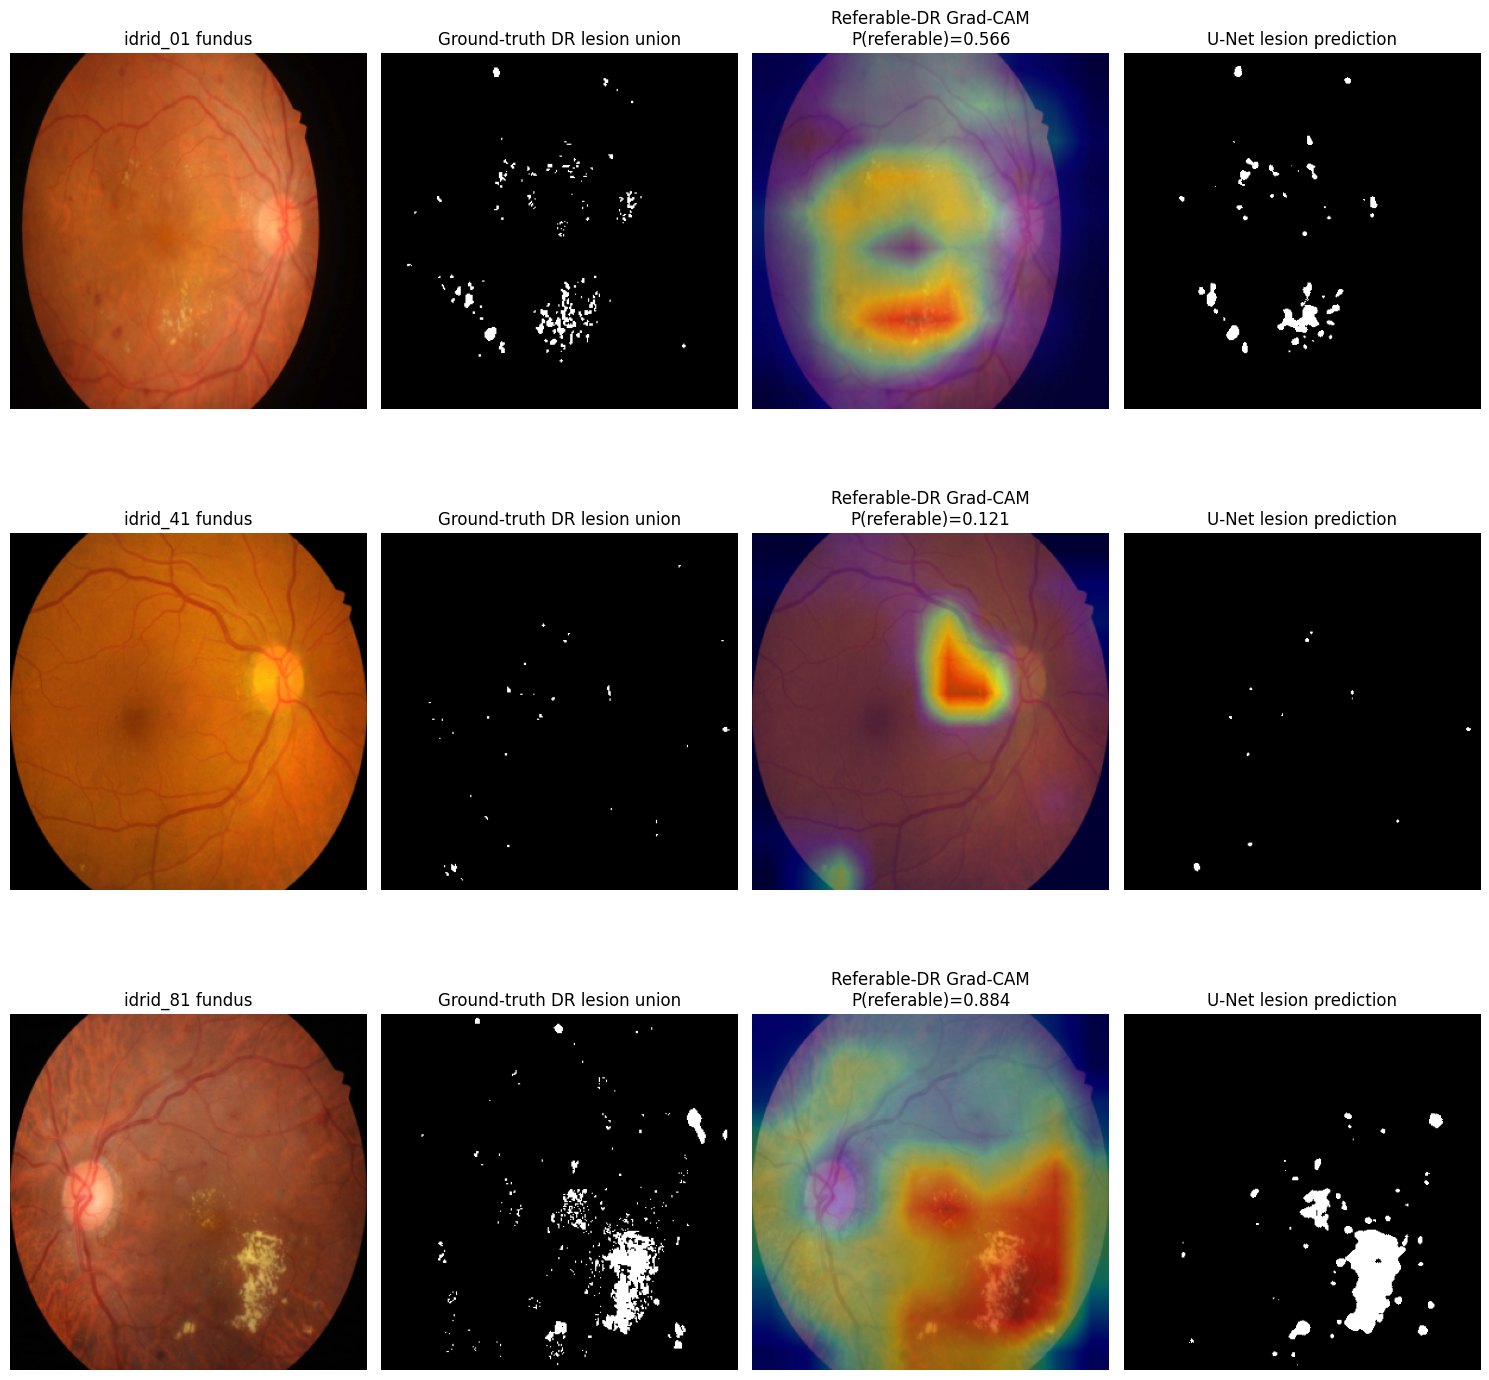

In [12]:
# Cell 12 — Plot representative explainability cases WITHOUT cherry-picking by IoU
# Cases are selected by deterministic ID order: first, middle, last.
show_indices = sorted(set([
    0,
    len(seg_df) // 2,
    len(seg_df) - 1,
]))

plt.figure(figsize=(15, 5 * len(show_indices)))

for row_num, idx in enumerate(show_indices):
    row = seg_df.iloc[idx]

    cls_img = load_classifier_image(row["filepath"])
    result = make_referable_gradcam(cls_img)
    cam = result["cam"]
    gt = idrid_union_at_classifier_size(row)

    seg_img = prepare_segmentation_image(row["filepath"])
    seg_prob = seg_model.predict(seg_img[None, ...], verbose=0)[0, ..., 0]
    seg_mask = seg_prob >= SEG_THRESHOLD

    cls_rgb = np.clip(cls_img / 255.0, 0, 1)
    cam_rgb = plt.get_cmap("jet")(cam)[..., :3]
    cam_overlay = np.clip(0.60 * cls_rgb + 0.40 * cam_rgb, 0, 1)

    plt.subplot(len(show_indices), 4, row_num * 4 + 1)
    plt.imshow(cls_rgb)
    plt.title(f"{row['base_id']} fundus")
    plt.axis("off")

    plt.subplot(len(show_indices), 4, row_num * 4 + 2)
    plt.imshow(gt, cmap="gray")
    plt.title("Ground-truth DR lesion union")
    plt.axis("off")

    plt.subplot(len(show_indices), 4, row_num * 4 + 3)
    plt.imshow(cam_overlay)
    plt.title(
        "Referable-DR Grad-CAM\n"
        f"P(referable)={result['referable_probability']:.3f}"
    )
    plt.axis("off")

    plt.subplot(len(show_indices), 4, row_num * 4 + 4)
    plt.imshow(seg_mask, cmap="gray")
    plt.title("U-Net lesion prediction")
    plt.axis("off")

plt.tight_layout()
plt.show()


# Replacement for the old Messidor-2 section

The old resolver failed because it depended too heavily on expected column names.

The replacement below:

- tries comma, semicolon, tab, and pipe delimiters;
- finds the image column by **actual filename overlap with the extracted Messidor images**, not by header text;
- detects a DR grade column by both semantic column-name scoring and its values;
- supports numeric grades and common textual grade labels;
- distinguishes a 0–4 adjudicated scale from a 0–3 original Messidor-style scale;
- always evaluates the binary **referable-DR** screening task when valid labels exist;
- computes five-class accuracy/QWK only when the external labels are genuinely on a 0–4 scale.


In [13]:
# Cell 13 — Resolve/extract Messidor-2 images
def resolve_messidor():
    direct_dirs = [
        DRIVE_ROOT / "Messidor2",
        DRIVE_ROOT / "MESSIDOR2",
        DRIVE_ROOT / "messidor2",
        DRIVE_ROOT / "IMAGES",
    ]

    for d in direct_dirs:
        if d.exists() and d.is_dir():
            imgs = index_images(d)
            if len(imgs) >= 100:
                print("Using already extracted Messidor folder:", d)
                return d

    parts = [DRIVE_ROOT / f"IMAGES.zip.{i:03d}" for i in range(1, 5)]

    if not all(p.exists() for p in parts):
        missing = [p.name for p in parts if not p.exists()]
        raise FileNotFoundError(
            "Missing Messidor image parts: " + ", ".join(missing)
        )

    out = WORK_ROOT / "Messidor2"
    marker = out / ".complete"

    if marker.exists():
        return out

    if out.exists():
        shutil.rmtree(out)
    out.mkdir(parents=True, exist_ok=True)

    combined = WORK_ROOT / "MESSIDOR_IMAGES.zip"

    try:
        print("Combining Messidor split archive...")
        with open(combined, "wb") as fo:
            for part in parts:
                print("  adding", part.name)
                with open(part, "rb") as fi:
                    shutil.copyfileobj(fi, fo, 16 * 1024 * 1024)

        with zipfile.ZipFile(combined) as z:
            bad = z.testzip()
            if bad:
                raise zipfile.BadZipFile(f"CRC failure: {bad}")
            z.extractall(out)

        marker.touch()
        return out

    except Exception as first_error:
        print("Direct concatenation extraction failed:", first_error)

    # Genuine multivolume fallback.
    subprocess.run(["apt-get", "update", "-qq"], check=True)
    subprocess.run(["apt-get", "install", "-y", "-qq", "p7zip-full"], check=True)

    result = subprocess.run(
        ["7z", "x", str(parts[0]), f"-o{out}", "-y"],
        capture_output=True,
        text=True,
    )

    if result.returncode != 0:
        raise RuntimeError(result.stderr[-3000:])

    marker.touch()
    return out

messidor_root = resolve_messidor()
messidor_images = index_images(messidor_root)

print("Messidor root:", messidor_root)
print("Messidor images found:", len(messidor_images))

if len(messidor_images) < 1000:
    print(
        "WARNING: fewer than 1000 Messidor images were found. "
        "Verify extraction before interpreting external metrics."
    )


Combining Messidor split archive...
  adding IMAGES.zip.001
  adding IMAGES.zip.002
  adding IMAGES.zip.003
  adding IMAGES.zip.004
Messidor root: /content/dr_resume_work/Messidor2
Messidor images found: 1748


In [14]:
# Cell 14 — Inspect ONLY the existing messidor-2.csv and infer its schema
MESSIDOR_CSV = DRIVE_ROOT / "messidor-2.csv"

if not MESSIDOR_CSV.exists():
    raise FileNotFoundError(
        f"Missing {MESSIDOR_CSV}. Transfer the existing messidor-2.csv file."
    )

def robust_read_csv(path):
    attempts = []

    try:
        df = pd.read_csv(path, sep=None, engine="python")
        attempts.append(("auto", df))
    except Exception:
        pass

    for sep, label in [
        (",", "comma"),
        (";", "semicolon"),
        ("\t", "tab"),
        ("|", "pipe"),
    ]:
        try:
            df = pd.read_csv(path, sep=sep)
            attempts.append((label, df))
        except Exception:
            pass

    attempts = [
        (label, df)
        for label, df in attempts
        if df is not None and len(df) > 0
    ]

    if not attempts:
        raise ValueError("Could not parse messidor-2.csv with common delimiters.")

    # Prefer the parse that exposes the richest table.
    attempts.sort(
        key=lambda item: (
            item[1].shape[1],
            int(item[1].notna().sum().sum()),
        ),
        reverse=True,
    )

    return attempts[0]

parse_label, raw = robust_read_csv(MESSIDOR_CSV)
raw = raw.copy()
raw.columns = [str(c).strip() for c in raw.columns]

print("=" * 72)
print("MESSIDOR CSV INSPECTION")
print("=" * 72)
print("File:", MESSIDOR_CSV)
print("Selected delimiter parse:", parse_label)
print("Shape:", raw.shape)
print("\nColumns:")
for c in raw.columns:
    print(" -", repr(c))

print("\nFirst rows:")
display(raw.head())

image_stems = set(messidor_images["stem"].str.lower())

path_by_stem = {}
for _, r in messidor_images.iterrows():
    path_by_stem.setdefault(r["stem"].lower(), r["filepath"])
    path_by_stem.setdefault(r["filename"].lower(), r["filepath"])

def normalize_image_key(value):
    s = str(value).strip().strip('"').strip("'")
    return Path(s).stem.lower()

def image_match_rate(series):
    keys = series.dropna().astype(str).map(normalize_image_key)
    if len(keys) == 0:
        return 0.0
    return float(keys.isin(image_stems).mean())

image_scores = {
    c: image_match_rate(raw[c])
    for c in raw.columns
}

print("\nImage-reference column candidates:")
for c, score in sorted(image_scores.items(), key=lambda x: x[1], reverse=True)[:10]:
    print(f" - {c!r}: filename match rate = {score:.3f}")

IMAGE_COL = max(image_scores, key=image_scores.get)
IMAGE_MATCH_RATE = image_scores[IMAGE_COL]

if IMAGE_MATCH_RATE < 0.20:
    print(
        "\nWARNING: No CSV column has strong direct overlap with the extracted "
        "Messidor image filenames. The file may use paired IDs or metadata identifiers."
    )
    IMAGE_COL = None
else:
    print("\nSelected image column:", IMAGE_COL)
    print("Image match rate:", IMAGE_MATCH_RATE)

TEXT_GRADE_MAP = {
    "no dr": 0,
    "no diabetic retinopathy": 0,
    "normal": 0,
    "none": 0,
    "mild": 1,
    "mild dr": 1,
    "moderate": 2,
    "moderate dr": 2,
    "severe": 3,
    "severe dr": 3,
    "proliferative": 4,
    "proliferative dr": 4,
    "pdr": 4,
}

def coerce_grade_series(series):
    numeric = pd.to_numeric(series, errors="coerce")
    numeric_valid = numeric.dropna()

    if len(numeric_valid) >= max(5, int(0.50 * len(series))):
        return numeric

    normalized = (
        series.astype(str)
        .str.strip()
        .str.lower()
        .str.replace("_", " ", regex=False)
        .str.replace("-", " ", regex=False)
    )

    mapped = normalized.map(TEXT_GRADE_MAP)

    mapped.loc[
        mapped.isna()
        & normalized.str.contains("proliferative", na=False)
    ] = 4
    mapped.loc[
        mapped.isna()
        & normalized.str.contains("severe", na=False)
    ] = 3
    mapped.loc[
        mapped.isna()
        & normalized.str.contains("moderate", na=False)
    ] = 2
    mapped.loc[
        mapped.isna()
        & normalized.str.contains("mild", na=False)
    ] = 1
    mapped.loc[
        mapped.isna()
        & normalized.str.contains(r"no\s+dr|normal|none", regex=True, na=False)
    ] = 0

    return mapped

def grade_column_score(name, series):
    grades = coerce_grade_series(series)
    valid = grades.dropna()

    if len(valid) < max(5, int(0.20 * len(series))):
        return -1e9, grades

    values = valid.to_numpy(dtype=float)
    rounded = np.round(values).astype(int)

    if np.mean(np.isclose(values, rounded)) < 0.90:
        return -1e9, grades

    if np.mean((rounded >= 0) & (rounded <= 4)) < 0.90:
        return -1e9, grades

    lname = str(name).strip().lower()
    score = 0.0

    for token, weight in [
        ("adjud", 7.0),
        ("retinopathy", 6.0),
        ("retino", 5.0),
        ("dr", 5.0),
        ("diagn", 3.0),
        ("grade", 3.0),
        ("severity", 2.0),
        ("level", 1.0),
    ]:
        if token in lname:
            score += weight

    for bad in [
        "dme",
        "edema",
        "oedema",
        "macular",
        "quality",
        "gradable",
        "gradability",
        "left",
        "right",
        "pair",
        "index",
    ]:
        if bad in lname:
            score -= 8.0

    # A real grade field should normally contain a small categorical scale.
    unique_values = np.unique(rounded)
    if len(unique_values) <= 5:
        score += 1.5
    score += 0.25 * len(unique_values)

    return score, grades

grade_candidates = []

for c in raw.columns:
    if IMAGE_COL is not None and c == IMAGE_COL:
        continue

    score, grades = grade_column_score(c, raw[c])

    if score <= -1e8:
        continue

    valid = grades.dropna()
    values = sorted(
        set(np.round(valid.to_numpy()).astype(int).tolist())
    )

    grade_candidates.append({
        "column": c,
        "score": float(score),
        "values": values,
        "valid_count": int(len(valid)),
        "grades": grades,
    })

grade_candidates.sort(
    key=lambda x: (x["score"], x["valid_count"]),
    reverse=True,
)

print("\nPossible DR-grade columns:")
if grade_candidates:
    for item in grade_candidates[:10]:
        print(
            f" - {item['column']!r}: score={item['score']:.2f}, "
            f"values={item['values']}, n={item['valid_count']}"
        )
else:
    print(" - none found")

MESSIDOR_EXTERNAL_AVAILABLE = False
GRADE_COL = None

if IMAGE_COL is not None and grade_candidates:
    best_grade = grade_candidates[0]

    # Require at least some semantic evidence that this is a DR field.
    # This avoids treating arbitrary integer metadata as disease grade.
    if best_grade["score"] >= 3.0:
        GRADE_COL = best_grade["column"]
        raw["__grade"] = best_grade["grades"]
        MESSIDOR_EXTERNAL_AVAILABLE = True

        print("\nSelected DR grade column:", GRADE_COL)
        print("Observed grade values:", best_grade["values"])
    else:
        print(
            "\nNo sufficiently trustworthy DR-grade column was found. "
            "The CSV contains numeric-looking data, but its semantics do not "
            "support treating it as diabetic-retinopathy grade."
        )

if not MESSIDOR_EXTERNAL_AVAILABLE:
    print(
        "\nExternal Messidor quantitative validation will be skipped. "
        "This is a data-label limitation, not a model-training failure. "
        "The notebook will continue without fabricating labels."
    )


MESSIDOR CSV INSPECTION
File: /content/drive/MyDrive/sih/messidor-2.csv
Selected delimiter parse: auto
Shape: (874, 2)

Columns:
 - 'left'
 - 'right'

First rows:


,left,right
0,20051109_57451_0400_PP.png,20051109_57843_0400_PP.png
1,20051109_59864_0400_PP.png,20051109_59751_0400_PP.png
2,20051109_60031_0400_PP.png,20051109_59969_0400_PP.png
3,20051110_33960_0400_PP.png,20051109_60136_0400_PP.png
4,20051110_34071_0400_PP.png,20051110_34013_0400_PP.png



Image-reference column candidates:
 - 'left': filename match rate = 1.000
 - 'right': filename match rate = 1.000

Selected image column: left
Image match rate: 1.0

Possible DR-grade columns:
 - none found

External Messidor quantitative validation will be skipped. This is a data-label limitation, not a model-training failure. The notebook will continue without fabricating labels.


In [15]:
# Cell 15 — Match Messidor labels to images when valid labels exist
ext = None
EXTERNAL_SCALE_MAX = None

if MESSIDOR_EXTERNAL_AVAILABLE:
    ext = raw.copy()

    ext["__key"] = ext[IMAGE_COL].map(normalize_image_key)
    ext["filepath"] = ext["__key"].map(path_by_stem)

    ext = ext.dropna(subset=["filepath", "__grade"]).copy()
    ext["label"] = np.round(ext["__grade"]).astype(int)
    ext = ext[ext["label"].between(0, 4)].reset_index(drop=True)

    print("Valid matched external rows:", len(ext))
    print("External grade distribution:")
    print(ext["label"].value_counts().sort_index())

    if len(ext) < 100:
        print(
            "\nWARNING: fewer than 100 labeled Messidor images were matched. "
            "External quantitative metrics will be skipped because the sample is too small."
        )
        MESSIDOR_EXTERNAL_AVAILABLE = False
        ext = None
    else:
        EXTERNAL_SCALE_MAX = int(ext["label"].max())

        if EXTERNAL_SCALE_MAX <= 3:
            print(
                "\nDetected a 0–3 external grading scale. "
                "Binary referable-DR metrics can be reported, but exact APTOS "
                "five-class accuracy/QWK will not be reported."
            )
        else:
            print(
                "\nDetected a 0–4 grading scale. "
                "Both referral metrics and exact-grade metrics can be reported."
            )
else:
    print("No trustworthy labeled external table is available; matching skipped.")


No trustworthy labeled external table is available; matching skipped.


In [16]:
# Cell 16 — External Messidor validation, if labels are genuinely available
messidor_results = None

def make_external_ds(df, batch_size=12):
    paths = df["filepath"].astype(str).values
    ds = tf.data.Dataset.from_tensor_slices(paths)
    ds = ds.map(
        lambda p: decode_classifier_image(p),
        num_parallel_calls=tf.data.AUTOTUNE,
    )
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

if MESSIDOR_EXTERNAL_AVAILABLE:
    ext_ds = make_external_ds(ext)

    ext_raw_probs = model.predict(ext_ds, verbose=1)
    ext_probs = temperature_scale(ext_raw_probs)

    y_ext = ext["label"].to_numpy()

    # For either a 0–3 or 0–4 DR scale:
    # 0/1 = non-referable, >=2 = referable.
    y_ext_ref = (y_ext >= 2).astype(int)
    p_ext_ref = ext_probs[:, 2:].sum(axis=1)
    pred_ext_ref = (p_ext_ref >= REF_THRESHOLD).astype(int)

    if len(np.unique(y_ext_ref)) < 2:
        print(
            "External labels contain only one referral class; "
            "ROC-AUC/sensitivity/specificity cannot be computed."
        )
        MESSIDOR_EXTERNAL_AVAILABLE = False
    else:
        ext_auc = roc_auc_score(y_ext_ref, p_ext_ref)

        tn, fp, fn, tp = confusion_matrix(
            y_ext_ref,
            pred_ext_ref,
            labels=[0, 1],
        ).ravel()

        ext_sensitivity = tp / (tp + fn) if (tp + fn) else np.nan
        ext_specificity = tn / (tn + fp) if (tn + fp) else np.nan

        messidor_results = {
            "n": int(len(ext)),
            "grade_scale_max": int(EXTERNAL_SCALE_MAX),
            "referable_auc": float(ext_auc),
            "sensitivity": float(ext_sensitivity),
            "specificity": float(ext_specificity),
            "referral_threshold": float(REF_THRESHOLD),
        }

        if EXTERNAL_SCALE_MAX == 4:
            pred_grade = np.argmax(ext_probs, axis=1)

            messidor_results["five_class_accuracy"] = float(
                accuracy_score(y_ext, pred_grade)
            )
            messidor_results["qwk"] = float(
                cohen_kappa_score(
                    y_ext,
                    pred_grade,
                    weights="quadratic",
                )
            )

        print("=" * 72)
        print("MESSIDOR-2 EXTERNAL VALIDATION")
        print("=" * 72)
        print(json.dumps(messidor_results, indent=2))

if messidor_results is None:
    print(
        "Messidor-2 quantitative external validation: NOT AVAILABLE "
        "from the labels contained in the existing messidor-2.csv."
    )


Messidor-2 quantitative external validation: NOT AVAILABLE from the labels contained in the existing messidor-2.csv.


In [17]:
# Cell 17 — Messidor external plots, only when valid external labels exist
if messidor_results is not None:
    fpr, tpr, roc_thresholds = roc_curve(y_ext_ref, p_ext_ref)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {ext_auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False positive rate")
    plt.ylabel("True positive rate / sensitivity")
    plt.title("Messidor-2 external referable-DR ROC")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()

    ConfusionMatrixDisplay.from_predictions(
        y_ext_ref,
        pred_ext_ref,
        labels=[0, 1],
        display_labels=["Non-referable", "Referable"],
    )
    plt.title("Messidor-2 external screening confusion matrix")
    plt.show()

    if EXTERNAL_SCALE_MAX == 4:
        pred_grade = np.argmax(ext_probs, axis=1)

        print("\nMessidor exact 5-class classification report:")
        print(
            classification_report(
                y_ext,
                pred_grade,
                labels=[0, 1, 2, 3, 4],
                zero_division=0,
            )
        )
else:
    print("External ROC/confusion-matrix plots skipped because valid Messidor DR labels are unavailable.")


External ROC/confusion-matrix plots skipped because valid Messidor DR labels are unavailable.


In [18]:
# Cell 18 — Save external predictions only when labels exist
messidor_csv_out = None

if messidor_results is not None:
    ext_results_df = ext[
        [IMAGE_COL, GRADE_COL, "filepath", "label"]
    ].copy()

    ext_results_df["referable_true"] = y_ext_ref
    ext_results_df["referable_probability"] = p_ext_ref
    ext_results_df["referable_prediction"] = pred_ext_ref

    if EXTERNAL_SCALE_MAX == 4:
        ext_results_df["predicted_grade"] = np.argmax(ext_probs, axis=1)

    messidor_csv_out = FIXED_OUTPUT_ROOT / "messidor_external_predictions.csv"
    ext_results_df.to_csv(messidor_csv_out, index=False)

    print("Saved:", messidor_csv_out)
else:
    print("No labeled external prediction CSV was created.")


No labeled external prediction CSV was created.


In [19]:
# Cell 19 — Corrected explainable review report
from reportlab.pdfgen import canvas
from reportlab.lib.pagesizes import A4

REPORT_DIR = FIXED_OUTPUT_ROOT / "reports"
REPORT_DIR.mkdir(parents=True, exist_ok=True)

def save_fixed_review_report(filepath, out_name):
    filepath = str(filepath)

    cls_img = load_classifier_image(filepath)
    cam_result = make_referable_gradcam(cls_img)

    cal_probs = cam_result["calibrated_probs"]
    pred_grade = cam_result["predicted_grade"]
    referable_prob = cam_result["referable_probability"]
    referral = referable_prob >= REF_THRESHOLD
    confidence = float(cal_probs[pred_grade])

    seg_img = prepare_segmentation_image(filepath)
    seg_prob = seg_model.predict(
        seg_img[None, ...],
        verbose=0,
    )[0, ..., 0]
    seg_binary = seg_prob >= SEG_THRESHOLD

    cls_rgb = np.clip(cls_img / 255.0, 0, 1)

    cam_rgb = plt.get_cmap("jet")(cam_result["cam"])[..., :3]
    cam_overlay = np.clip(
        0.60 * cls_rgb + 0.40 * cam_rgb,
        0,
        1,
    )

    seg_rgb = np.clip(seg_img / 255.0, 0, 1)
    lesion_color = np.zeros_like(seg_rgb)
    lesion_color[..., 0] = seg_binary.astype(np.float32)

    seg_overlay = np.clip(
        0.75 * seg_rgb + 0.50 * lesion_color,
        0,
        1,
    )

    png_path = REPORT_DIR / f"{out_name}.png"

    fig, ax = plt.subplots(1, 3, figsize=(15, 5))

    ax[0].imshow(cls_rgb)
    ax[0].set_title("Fundus image")
    ax[0].axis("off")

    ax[1].imshow(cam_overlay)
    ax[1].set_title(
        "Referable-DR Grad-CAM\n"
        f"P(referable)={referable_prob:.3f}"
    )
    ax[1].axis("off")

    ax[2].imshow(seg_overlay)
    ax[2].set_title(
        "U-Net DR-lesion localization\n"
        f"threshold={SEG_THRESHOLD:.2f}"
    )
    ax[2].axis("off")

    plt.tight_layout()
    plt.savefig(png_path, dpi=160, bbox_inches="tight")
    plt.close()

    pdf_path = REPORT_DIR / f"{out_name}.pdf"

    c = canvas.Canvas(str(pdf_path), pagesize=A4)

    c.drawString(40, 810, "Explainable DR Screening Review")
    c.drawString(40, 790, f"Predicted DR grade: {pred_grade}")
    c.drawString(40, 770, f"Calibrated grade confidence: {confidence:.3f}")
    c.drawString(40, 750, f"Referable-DR probability: {referable_prob:.3f}")
    c.drawString(
        40,
        730,
        f"Referral decision: {'REFER' if referral else 'NON-REFER'}"
    )
    c.drawString(40, 710, "Localized explanation: U-Net lesion mask")
    c.drawString(40, 690, "Auxiliary explanation: referable-score Grad-CAM")

    c.drawImage(
        str(png_path),
        35,
        235,
        width=525,
        height=410,
        preserveAspectRatio=True,
        anchor="c",
    )

    c.drawString(
        40,
        200,
        "Screening decision-support prototype only; not a clinical diagnosis."
    )

    c.save()

    return {
        "png": str(png_path),
        "pdf": str(pdf_path),
        "grade": int(pred_grade),
        "calibrated_confidence": confidence,
        "referable_probability": float(referable_prob),
        "referral": bool(referral),
    }

# A quantitative label is NOT required to demonstrate inference/report generation.
if len(messidor_images):
    report_sample_path = messidor_images.iloc[0]["filepath"]
    report_source = "Messidor-2 unlabeled inference sample"
else:
    report_sample_path = seg_df.iloc[0]["filepath"]
    report_source = "IDRiD inference sample"

sample_fixed_report = save_fixed_review_report(
    report_sample_path,
    "sample_external_review",
)

print("Report source:", report_source)
print(json.dumps(sample_fixed_report, indent=2))


Report source: Messidor-2 unlabeled inference sample
{
  "png": "/content/drive/MyDrive/sih/outputs_v3_fixed/reports/sample_external_review.png",
  "pdf": "/content/drive/MyDrive/sih/outputs_v3_fixed/reports/sample_external_review.pdf",
  "grade": 0,
  "calibrated_confidence": 0.9968531526939622,
  "referable_probability": 0.0014165282642771824,
  "referral": false
}


In [20]:
# Cell 20 — Final combined benchmark and handoff summary
internal_classifier = previous_summary["classifier"]
internal_seg = previous_summary["segmentation"]

classification_rows = [
    {
        "dataset": "APTOS held-out test",
        "n": int(previous_summary.get("aptos_test_rows", 550)),
        "five_class_accuracy": internal_classifier.get("aptos_test_accuracy"),
        "qwk": internal_classifier.get("aptos_test_qwk"),
        "referable_auc": internal_classifier.get("aptos_test_referable_auc"),
        "sensitivity": internal_classifier.get("aptos_test_sensitivity"),
        "specificity": internal_classifier.get("aptos_test_specificity"),
        "status": "validated",
    }
]

if messidor_results is not None:
    classification_rows.append(
        {
            "dataset": "Messidor-2 external",
            "n": messidor_results["n"],
            "five_class_accuracy": messidor_results.get("five_class_accuracy"),
            "qwk": messidor_results.get("qwk"),
            "referable_auc": messidor_results["referable_auc"],
            "sensitivity": messidor_results["sensitivity"],
            "specificity": messidor_results["specificity"],
            "status": "validated from messidor-2.csv labels",
        }
    )
else:
    classification_rows.append(
        {
            "dataset": "Messidor-2 external",
            "n": np.nan,
            "five_class_accuracy": np.nan,
            "qwk": np.nan,
            "referable_auc": np.nan,
            "sensitivity": np.nan,
            "specificity": np.nan,
            "status": "not quantitatively evaluable: no trustworthy DR-grade labels detected",
        }
    )

classification_df = pd.DataFrame(classification_rows)

segmentation_df = pd.DataFrame([
    {
        "dataset": "IDRiD validation",
        "dice": internal_seg.get("validation_dice"),
        "iou": internal_seg.get("validation_iou"),
        "precision": internal_seg.get("validation_precision"),
        "recall": internal_seg.get("validation_recall"),
        "threshold": internal_seg.get("validation_threshold"),
    }
])

display(classification_df)
display(segmentation_df)

classification_df.to_csv(
    FIXED_OUTPUT_ROOT / "final_classification_benchmark.csv",
    index=False,
)

segmentation_df.to_csv(
    FIXED_OUTPUT_ROOT / "final_segmentation_benchmark.csv",
    index=False,
)

fixed_summary = {
    "source_run": previous_summary,
    "remaining_sections_fixed": True,
    "messidor_external": messidor_results,
    "messidor_external_status": (
        "quantitative validation completed"
        if messidor_results is not None
        else "messidor-2.csv did not provide trustworthy DR-grade labels; "
             "quantitative external validation skipped"
    ),
    "gradcam_auxiliary": {
        "n": int(len(cam_df)),
        "median_iou_top20pct": float(cam_df["cam_iou80"].median()),
        "mean_iou_top20pct": float(cam_df["cam_iou80"].mean()),
        "median_attention_enrichment": float(
            cam_df["attention_enrichment"].median()
        ),
        "pointing_hit_rate": float(cam_df["pointing_hit"].mean()),
        "note": (
            "Grad-CAM is an auxiliary classifier-attention diagnostic. "
            "U-Net segmentation is the primary localized lesion explanation."
        ),
    },
    "fixed_output_root": str(FIXED_OUTPUT_ROOT),
}

with open(
    FIXED_OUTPUT_ROOT / "final_fixed_summary.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(fixed_summary, f, indent=2, default=str)

print("\nSaved corrected outputs:")
for p in sorted(FIXED_OUTPUT_ROOT.rglob("*")):
    if p.is_file():
        print(" -", p.relative_to(FIXED_OUTPUT_ROOT))


,dataset,n,five_class_accuracy,qwk,referable_auc,sensitivity,specificity,status
0,APTOS held-out test,550.0,0.772727,0.820173,0.969885,0.90583,0.889908,validated
1,Messidor-2 external,NaN,NaN,NaN,NaN,NaN,NaN,not quantitatively evaluable: no trustworthy D...


,dataset,dice,iou,precision,recall,threshold
0,IDRiD validation,0.54354,0.373193,0.507384,0.585244,0.85



Saved corrected outputs:
 - final_classification_benchmark.csv
 - final_fixed_summary.json
 - final_segmentation_benchmark.csv
 - idrid_referable_gradcam_metrics.csv
 - reports/sample_external_review.pdf
 - reports/sample_external_review.png


## What changed relative to the old Cells 34–39

### Grad-CAM
The old code used a single image and compared the predicted-class CAM directly with lesion masks. The replacement uses a **referable-DR Grad-CAM target** and evaluates every available IDRiD case. The U-Net segmentation remains the primary localized lesion explanation; Grad-CAM is only an auxiliary attention diagnostic.

### Messidor-2
The notebook now uses **only the existing `messidor-2.csv`**. It no longer assumes the existence of any other Messidor label file.

It:

- detects the delimiter,
- prints the real schema and sample rows,
- looks for an image-reference column by matching values against actual extracted filenames,
- looks for a plausible DR-grade field by both semantic column-name evidence and its values,
- refuses to reinterpret unrelated integer metadata as disease grade.

If trustworthy grades are found, external AUC/sensitivity/specificity are computed. If they are not present, external quantitative validation is marked unavailable and the notebook continues normally.

### Checkpoint loading
The segmentation model is rebuilt with `weights=None` and then receives the already-trained final weights. This avoids unnecessary pretrained-weight downloads and optimizer-state warnings.

### No retraining
There is no classifier or U-Net `fit()` call in this notebook. The validated checkpoints and thresholds from the successful previous run are reused exactly.
